# RoBERTa Model

In [ ]:
# import all libraries
import requests
from bs4 import BeautifulSoup
import re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification

/Users/anthonykamau/anaconda3/envs/nlp_bert/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [ ]:

# function for pre-processing
def clean_text(text):
    # Remove zero‑width spaces (HTML encoded)
    text = re.sub(r'&#x200B;', ' ', text)

    # Remove Reddit system markers
    text = re.sub(r'\[removed\]\[deleted\]', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Collapse multiple spaces / newlines
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [3]:
import pandas as pd
reddit_data = pd.read_csv('/Users/anthonykamau/Desktop/reddit_data.csv')

In [4]:
# Separate dataframes for each TV show
df_got = reddit_data[(reddit_data["title"] == "Game of Thrones") & (reddit_data["year"] == 2017)]


df_bcs = reddit_data[(reddit_data["title"] == "Better Call Saul") & (reddit_data["year"] == 2020)]

In [5]:
df_got["clean_post"] = df_got["post"].astype(str).apply(clean_text)
df_bcs["clean_post"] = df_bcs["post"].astype(str).apply(clean_text)

/var/folders/c1/5z8fscn948z2w8k8m6212smr0000gn/T/ipykernel_11374/3607074616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_got["clean_post"] = df_got["post"].astype(str).apply(clean_text)
/var/folders/c1/5z8fscn948z2w8k8m6212smr0000gn/T/ipykernel_11374/3607074616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bcs["clean_post"] = df_bcs["post"].astype(str).apply(clean_text)


In [ ]:
# Load the pre-trained sentiment analysis model and tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

In [ ]:
# function for batch sentiment classification
def batch_sentiment(posts, batch_size=64, max_length=128):
    all_scores = []

    for i in range(0, len(posts), batch_size):
        batch = posts[i:i+batch_size].tolist()

        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            output = model(**tokens)

        scores = torch.argmax(output.logits, dim=1)
        all_scores.extend(scores.cpu().tolist())

    return all_scores


In [ ]:
df_got["sentiments"] = batch_sentiment(df_got["clean_post"])
df_bcs["sentiments"] = batch_sentiment(df_bcs["clean_post"])

In [10]:
df_got.to_csv(
    "/Users/anthonykamau/Desktop/text_media/RoBert_got.csv",
    index=False)


df_bcs.to_csv(
    "/Users/anthonykamau/Desktop/text_media/RoBert_bcs.csv",
    index=False)

In [13]:
df_got["sentiments"].value_counts()

sentiments
1    1807
0    1349
2     747
Name: count, dtype: int64

<Axes: title={'center': 'Sentiment Distribution for Game of Thrones Posts (2017)'}, xlabel='sentiments'>

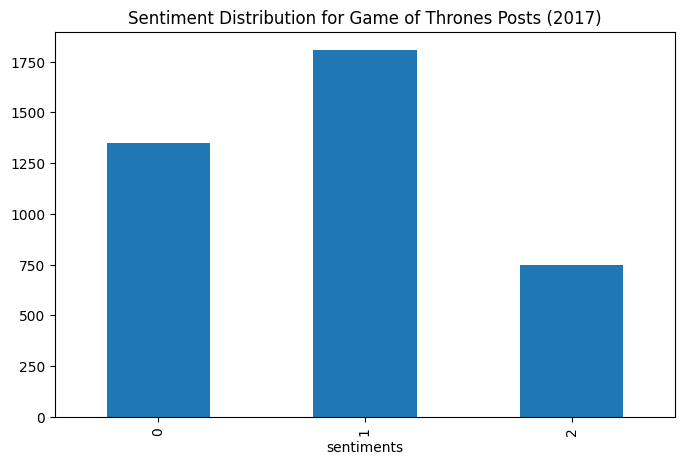

In [16]:
freq_got = df_got["sentiments"].value_counts().sort_index()
freq_got.plot(kind="bar", figsize=(8,5), title="Sentiment Distribution for Game of Thrones Posts (2017)")

In [14]:
df_bcs["sentiments"].value_counts()

sentiments
1    608
0    443
2    208
Name: count, dtype: int64

<Axes: title={'center': 'Sentiment Distribution for Better Call Saul Posts (2020)'}, xlabel='sentiments'>

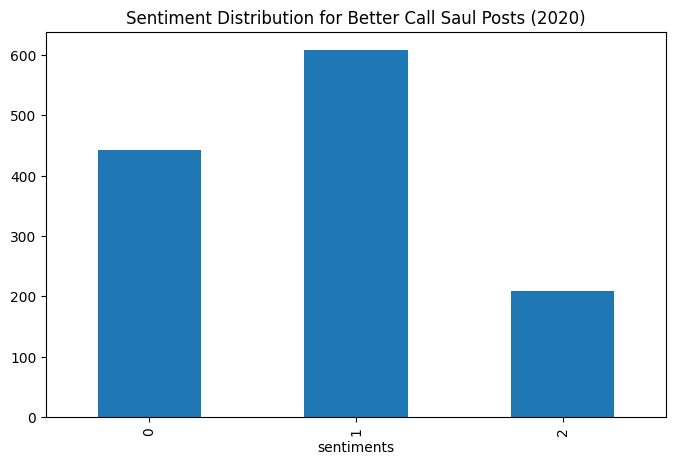

In [15]:
freq_bcs = df_bcs["sentiments"].value_counts().sort_index()
freq_bcs.plot(kind="bar", figsize=(8,5), title="Sentiment Distribution for Better Call Saul Posts (2020)")

In [ ]:
import matplotlib.pyplot as plt

# Calculate frequencies
freq_got = df_got["sentiments"].value_counts().sort_index()
freq_bcs = df_bcs["sentiments"].value_counts().sort_index()

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Game of Thrones
freq_got.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Sentiment Distribution for Game of Thrones Posts (2017)")
axes[0].set_xlabel("Sentiment Class")
axes[0].set_ylabel("Frequency")

# Plot Better Call Saul
freq_bcs.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Sentiment Distribution for Better Call Saul Posts (2020)")
axes[1].set_xlabel("Sentiment Class")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()
